In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import gpflow as gp

In [88]:
np.random.seed(0)
X = np.random.uniform(0, 5, 10)[:, None]
y = np.sin((X - 2.5) ** 2) # + np.random.normal(scale=.1, size=25)[:, None]

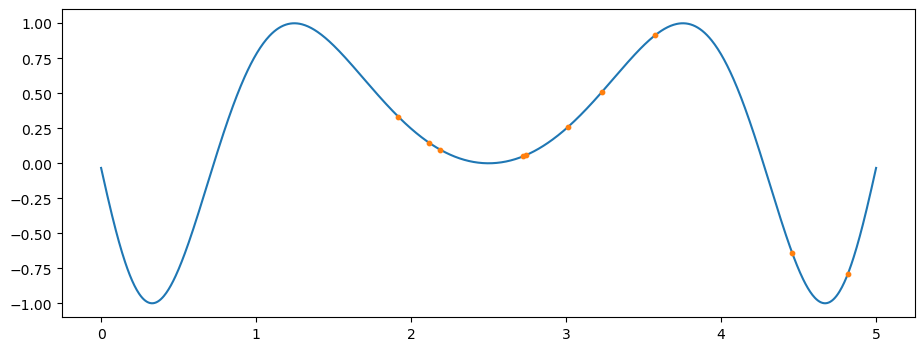

In [89]:
fig, ax = plt.subplots(figsize=(11, 4))
plt.plot(np.linspace(0, 5, 1000), np.sin((np.linspace(0, 5, 1000) - 2.5) ** 2))
plt.scatter(X, y, s=10, c='tab:orange', zorder=10)

In [109]:
kernel = gp.kernels.RBF(variance=1, lengthscales=1)
gp.utilities.set_trainable(kernel.variance, False)
#gp.utilities.set_trainable(model.likelyhood.variance, False)

model = gp.models.GPR(data=(X, y), kernel=kernel)
optimizer = gp.optimizers.Scipy()

gp.utilities.print_summary(model)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ False       │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════

In [110]:
opt_min = optimizer.minimize(
    model.training_loss, model.trainable_variables, options=dict(maxiter=10))

In [111]:
Xnew = np.linspace(0, 5, 1000)[:, None]
ynew, var = model.predict_f(Xnew)

Xnew = Xnew[:, 0]
ynew = np.array(ynew[:, 0])
std = np.sqrt(var)[:, 0]

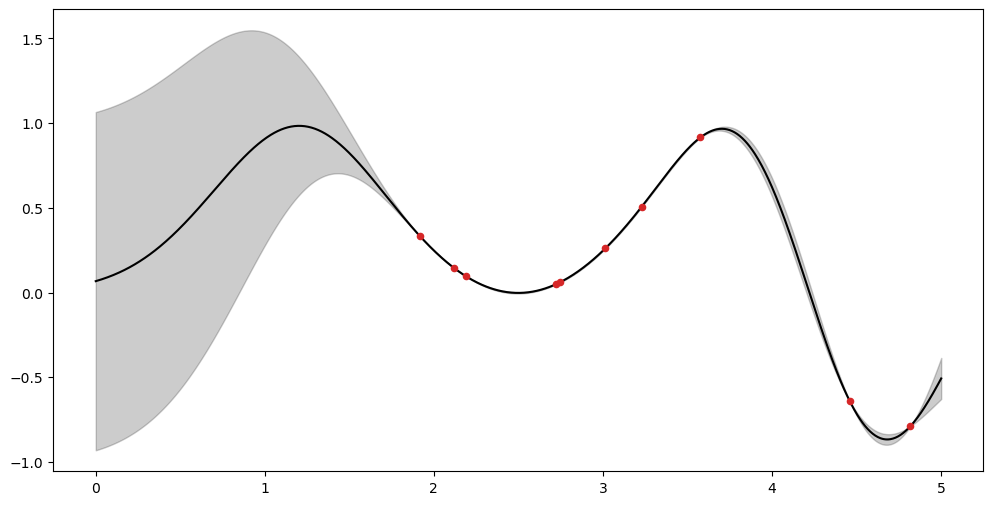

In [112]:
fig, ax = plt.subplots(figsize=(12, 6))
#plt.plot(np.linspace(0, 10, 1000), np.sin(np.linspace(0, 10, 1000)))
plt.fill_between(Xnew, ynew - std, ynew + std, alpha=.2, color='black')
plt.plot(Xnew, ynew, color='black')
plt.scatter(X, y, s=20, c='tab:red', zorder=10)

In [113]:
gp.utilities.print_summary(model)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ False       │ ()      │ float64 │ 1       │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.61014 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 0       │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════